In [55]:
from pathlib import Path

import pyvista as pv
import pandas as pd
import meshio
import numpy as np
import matplotlib.pyplot as plt

from volume_reader import get_volume_at_time

In [3]:
# Define the path to your folder
folder_path = Path("../Data/Gilbert/Thigh_pad/full_compress") # Use forward slashes for cross-platform compatibility

# Loop through all items in the directory
dfs_data = []
for file_path in folder_path.iterdir():
    # Check if the current item is a file
    if file_path.is_file():
        print(f"Loading file {file_path}")
        dfs_data.append(pd.read_csv(file_path))

Loading file ../Data/Gilbert/Thigh_pad/full_compress/003046_combined_synced.csv
Loading file ../Data/Gilbert/Thigh_pad/full_compress/002502_combined_synced.csv
Loading file ../Data/Gilbert/Thigh_pad/full_compress/002938_combined_synced.csv
Loading file ../Data/Gilbert/Thigh_pad/full_compress/002052_combined_synced.csv
Loading file ../Data/Gilbert/Thigh_pad/full_compress/002829_combined_synced.csv


Dataset 0, Compression start at -1.740, Compression end at -2.190, dx is -0.450
Dataset 1, Compression start at -1.720, Compression end at -2.190, dx is -0.470
Dataset 2, Compression start at -1.730, Compression end at -2.190, dx is -0.460
Dataset 3, Compression start at -1.710, Compression end at -2.190, dx is -0.480
Dataset 4, Compression start at -1.730, Compression end at -2.190, dx is -0.460
Mean dx: -0.46399999999999997


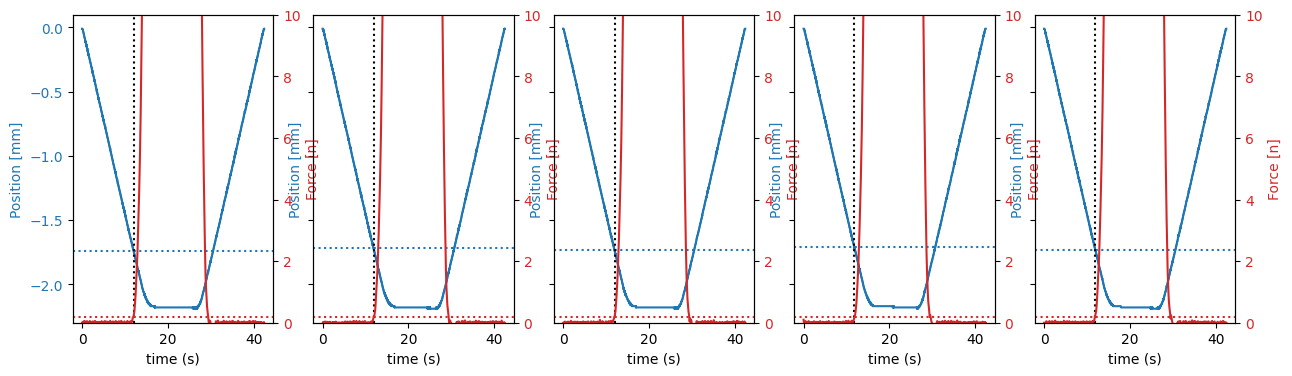

In [79]:
#ax, figure = plt.subplots()
def plot_pos_and_force_over_time(df_data, ax1):    
    color = 'tab:blue'
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('Position [mm]', color=color)
    ax1.plot(df_data["time_s"], df_data["position_mm"], color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
    
    color = 'tab:red'
    ax2.set_ylabel('Force [n]', color=color)  # we already handled the x-label with ax1
    ax2.plot(df_data["time_s"], df_data["force_N"], color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    ax2.set_ylim([0, 10])
    return ax1, ax2

def get_compression_posns(df_data, force_threshold):
    mask_compressing = df_data_i["force_N"] > force_threshold
    i_compression_start = np.nonzero(mask_compressing)[0][0]
    x_compression_start = df_data_i["position_mm"][i_compression_start]

    # Now compare against the bottomed out position to find the dx
    x_bottom = np.min(df_data_i["position_mm"])
    

    return i_compression_start, x_compression_start, x_bottom
    

force_threshold = 0.2 # [N] - what we are considering to be start of real compression
dxs = []
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(15, 4), sharey=True)
for i, df_data_i in enumerate(dfs_data):
    ax1, ax2 = plot_pos_and_force_over_time(df_data_i, axs[i])

    i_compression_start, x_compression_start, x_bottom = get_compression_posns(df_data_i, force_threshold)
    dx_compression = x_bottom - x_compression_start

    # Print output and plot values as h and v lines
    print(f"Dataset {i:1d}, Compression start at {x_compression_start:.3f}, Compression end at {x_bottom:.3f}, dx is {dx_compression:.3f}")
    ax1.axhline(y=x_compression_start, color="tab:blue", linestyle=":")
    ax2.axhline(y=force_threshold, color="tab:red", linestyle=":")
    ax1.axvline(x=df_data_i["time_s"][i_compression_start], color="k", linestyle=":")

    dxs.append(dx_compression)
print(f"Mean dx: {np.mean(dxs)}")

Using this dx value, we run the simulation with PolyFEM. Here are the results.

In [59]:
read_from_pvd = False
csv_path = "../Thigh-pad/six-channel/sim_outputs/sim_without_cavity_full-compression_try1/sim_pressures.csv"

if read_from_pvd:
    filename = "../Thigh-pad/six-channel/sim_outputs/sim_without_cavity_full-compression_try1/sim.pvd"
    reader = pv.get_reader(filename)
    
    id_interior = 2
    v_0 = get_volume_at_time(reader, 0, id_interior)
    ps = []
    vs = []
    
    for t in reader.time_values:
        v_t = get_volume_at_time(reader, t, id_interior)
        p_t_ratio = v_0/v_t
        vs.append(v_t)
        ps.append(p_t_ratio)
    
    df_sim_result = pd.DataFrame({"times": reader.time_values, "volumes": vs, "pressures": ps})
    df_sim_result.to_csv(csv_path, index=False)
else:
    df_sim_result = pd.read_csv(csv_path)

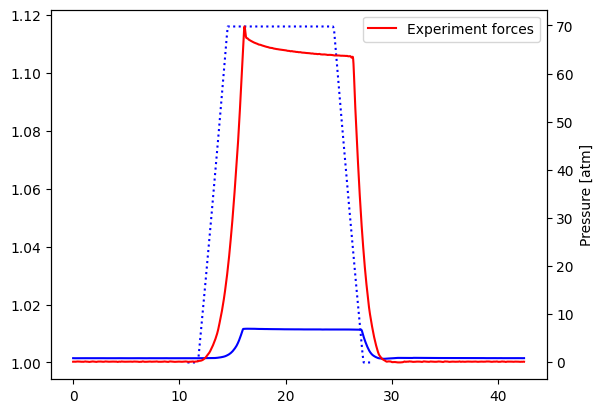

In [94]:
i_df_data = 0
df_data_i = dfs_data[i_df_data]
i_compression_start, x_compression_start, x_bottom = get_compression_posns(df_data_i, 0.1)
t_compression_start = df_data_i["time_s"][i_compression_start]
t_sim_start = t_compression_start - 1
t_sim_end = t_sim_start + 17.5

i_sim_start = np.argmin(np.abs(df_data_i["time_s"] - t_sim_start))
i_sim_end = np.argmin(np.abs(df_data_i["time_s"] - t_sim_end))

# Plot my sim result against gilberts
fig, ax1 = plt.subplots()
ax1.plot(df_sim_result["times"] + t_sim_start, df_sim_result["pressures"], color="b", linestyle=":", label="Simulated pressures")
ax1.plot(df_data_i["time_s"], df_data_i["pressure_atm"] + 1, color="b", label="Experiment pressures")

ax2 = ax1.twinx()
ax2.plot(df_data_i["time_s"], df_data_i["force_N"], color="r", label="Experiment forces")
plt.xlabel("Time [s]")
plt.ylabel("Pressure [atm]")
plt.legend()